In [1]:
import torch
torch.cuda.empty_cache()

In [2]:
torch.cuda.memory_summary(device=None, abbreviated=False)

'|===========================================================================|\n|                  PyTorch CUDA memory summary, device ID 0                 |\n|---------------------------------------------------------------------------|\n|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |\n|===========================================================================|\n|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |\n|---------------------------------------------------------------------------|\n| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |\n|       from large pool |      0 B   |      0 B   |      0 B   |      0 B   |\n|       from small pool |      0 B   |      0 B   |      0 B   |      0 B   |\n|---------------------------------------------------------------------------|\n| Active memory         |      0 B   |      0 B   |      0 B   |      0 B   |\n|       from large pool |      0 B   |      0 B   |

In [3]:
!pip install git+https://github.com/huggingface/accelerate.git

  Cloning https://github.com/huggingface/accelerate.git to /tmp/pip-req-build-zmmju83b
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/accelerate.git /tmp/pip-req-build-zmmju83b
  Resolved https://github.com/huggingface/accelerate.git to commit 29e03d185d6c4608472b3b866964c8942c2fa4a3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for accelerate: filename=accelerate-1.14.0.dev0-py3-none-any.whl size=386923 sha256=9c668efa44574004ab20a8e34b2783ce8ddaec240b0f49023b257c6989f94beb
  Stored in directory: /tmp/pip-ephem-wheel-cache-j0aoocv2/wheels/5a/20/fb/1221fe933b56fe7ac69fd00159d9a1950bc8ced38198abc18f
Successfully built accelerate
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.13.0
    Uninstalling accelerate-1.13.0:
      Successfully uninstalled accelerate-1.13.0


In [4]:
!pip install git+https://github.com/huggingface/transformers.git

  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-z5yt_blg
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-z5yt_blg
  Resolved https://github.com/huggingface/transformers.git to commit 3ef278124e47832f34406ca3ca85bc50ad8b79bb
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for transformers: filename=transformers-5.8.0.dev0-py3-none-any.whl size=11879936 sha256=f1f93d2e11438db2609d78781a12dd05bc00d6f81a772fb479b0883f67a61b0a
  Stored in directory: /tmp/pip-ephem-wheel-cache-ihtfv5u6/wheels/54/cb/3f/83103de5575c534436d6a4686686dead458238dfaf1147e98d
Successfully built transformers
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [5]:
!pip install -U bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 48.4 MB/s eta 0:00:00


In [6]:
"""from transformers import AutoModel

access_token = "hf_XX"""

'from transformers import AutoModel\n\naccess_token = "hf_XX'

In [7]:
from google.colab import userdata

hf_token = userdata.get('Allam')

In [8]:
from huggingface_hub import login
login(token=hf_token)

In [9]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/IMDB Dataset.csv')
df.head()


Mounted at /content/drive


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [10]:
import re
import string

def preprocess_text(text):

    text = text.lower()

    text = re.sub(r"<.*?>", "", text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    text = re.sub(r"\s+", " ", text).strip()

    return text

In [11]:
def prompt(text):

    return f"""Classify the sentiment of this movie review as positive or negative.
            Return only one word: positive or negative.
            Review:{text}"""

In [12]:
import io
import pandas as pd
import subprocess
import sys
import gc
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch, re, os

final_translation = []


model_name = "humain-ai/ALLaM-7B-Instruct-preview"

allam_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto"

)

tokenizer = AutoTokenizer.from_pretrained(model_name)

def model(query):


    messages = [
    {"role": "user", "content": query},
]
    inputs = tokenizer.apply_chat_template(messages, tokenize=False)
    inputs = tokenizer(inputs, return_tensors='pt', return_token_type_ids=False)
    inputs = {k: v.to(allam_model.device) for k, v in inputs.items()}

    max_input_length = tokenizer.model_max_length
    if len(inputs['input_ids'][0]) > max_input_length:
        print(f"Warning: Input text length ({len(inputs['input_ids'][0])}) exceeds the model's maximum input length ({max_input_length}).")

        inputs['input_ids'] = inputs['input_ids'][:, :max_input_length]
        inputs['attention_mask'] = inputs['attention_mask'][:, :max_input_length]
    response = allam_model.generate(**inputs, max_new_tokens=20, do_sample=False)
    output_tokens = response[0][inputs["input_ids"].shape[-1]:]
    generated_text = tokenizer.decode(output_tokens, skip_special_tokens=True)
    generated_text = generated_text.lower().strip()
    print(generated_text)
    if "positive" in generated_text:
        prediction = "positive"
    elif "negative" in generated_text:
        prediction = "negative"
    else:
      prediction = "negative"

    return prediction


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/686 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

In [13]:
review = "This movie was amazing and enjoyable."

query = prompt(review)

prediction = model(query)

print(prediction)

[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


positive
positive


In [14]:
review = "This movie was boring and disappointing."

query = prompt(review)

prediction = model(query)

print(prediction)

[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


negative
negative


In [18]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

sample_df = df.sample(1000, random_state=42).copy()

sample_df["predicted_sentiment"] = sample_df["review"].apply(
    lambda x: model(prompt(preprocess_text(x)))
)

y_true = sample_df["sentiment"]
y_pred = sample_df["predicted_sentiment"]

print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))

[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


negative
positive
negative
positive


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


negative
positive
positive
positive


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


...

negative
positive
negative
negative


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


negative
negative
negative
positive


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


positive
negative
Accuracy: 0.959
              precision    recall  f1-score   support

    negative       0.95      0.98      0.96       524
    positive       0.97      0.94      0.96       476

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



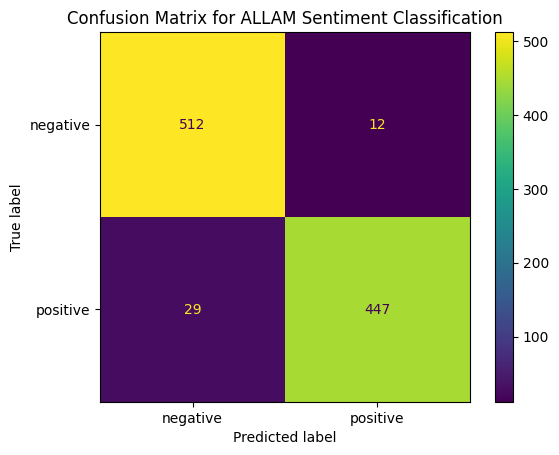

In [19]:
cm = confusion_matrix(y_true, y_pred, labels=["negative", "positive"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["negative", "positive"]
)

disp.plot()
plt.title("Confusion Matrix for ALLAM Sentiment Classification")
plt.show()

In [20]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Classification Report:")
print(classification_report(y_true, y_pred))

Classification Report:
              precision    recall  f1-score   support

    negative       0.95      0.98      0.96       524
    positive       0.97      0.94      0.96       476

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000

